[\[GitHub\] Jupyter Notebook](https://github.com/sslastochkin/mcab/blob/main/docs/guide/04_reproducibility_seeds.ipynb)

# Reproducibility and Seeds  
  
Monte Carlo simulations are inherently random — each run shuffles users into groups
differently. Without careful seed management, you can't tell whether a change in
results comes from a meaningful code edit or from random variation.

This guide covers two levels of reproducibility in `mcab`:

1. **Data reproducibility** — getting the same synthetic dataset every time
   (`RandomData` seed)
2. **Simulation reproducibility** — getting the same p-value distribution every time
   (`Designer` seed)

And three practical scenarios where it matters:

- Repeating results in a Jupyter notebook
- Switching between sequential (`n_jobs=1`) and parallel (`n_jobs=-1`) execution
- Running simulations from a Python script


## Where seeds live in `mcab`

Reproducibility in `mcab` has two links in the chain:

1. **`RandomData(seed=)`** — controls which data you feed into the designer.
   Different data → different simulation statistics.
2. **`DesignerIid(target, seed=)`** — controls how the designer shuffles that data
   across simulations. Different designer seed → different p-value sequence.

Both must be fixed to get the same simulation results end to end.


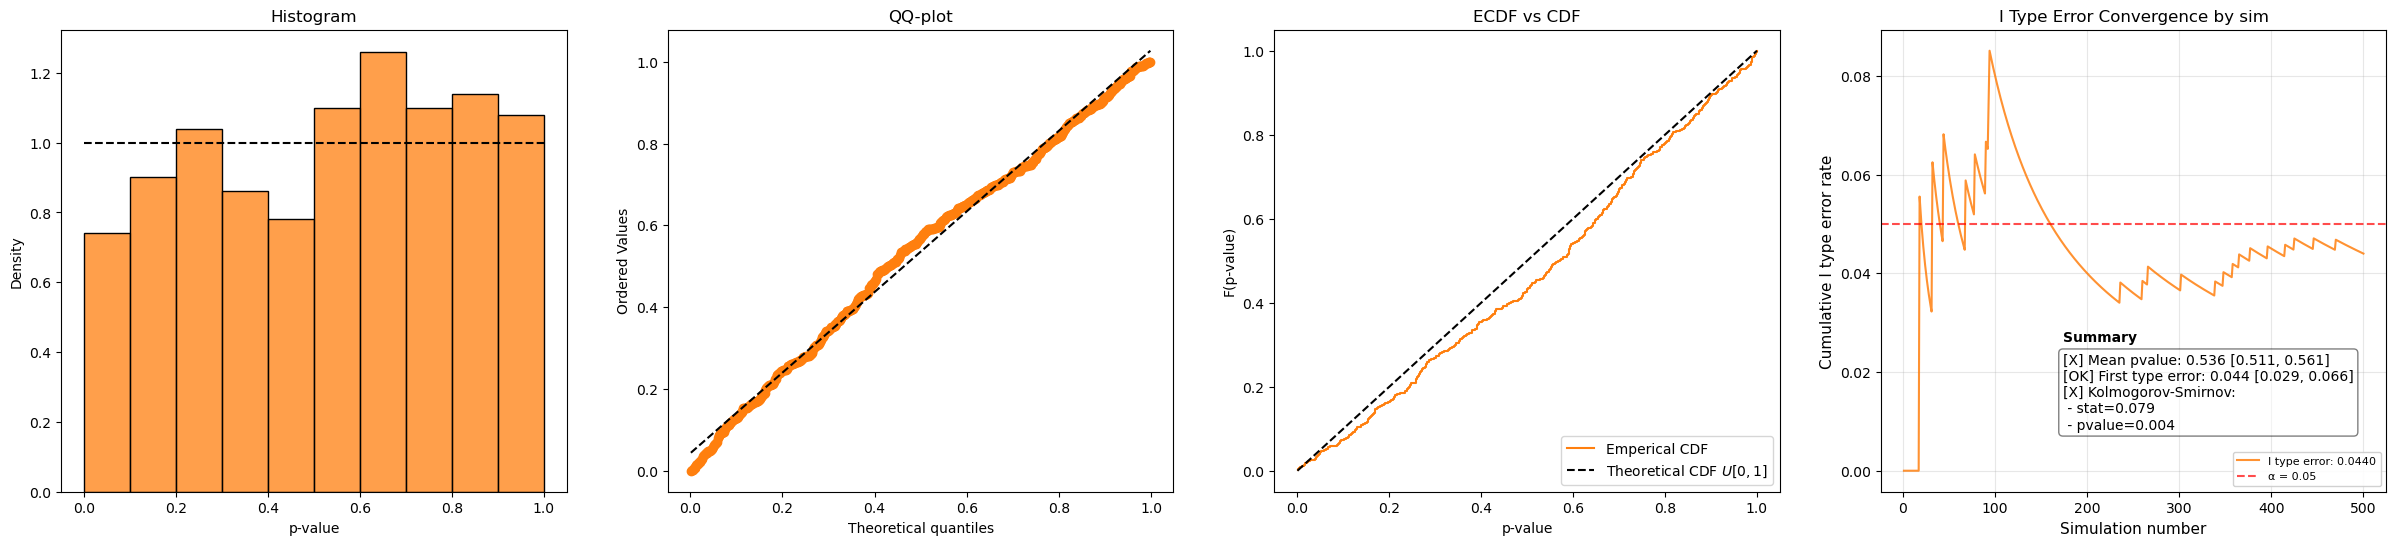

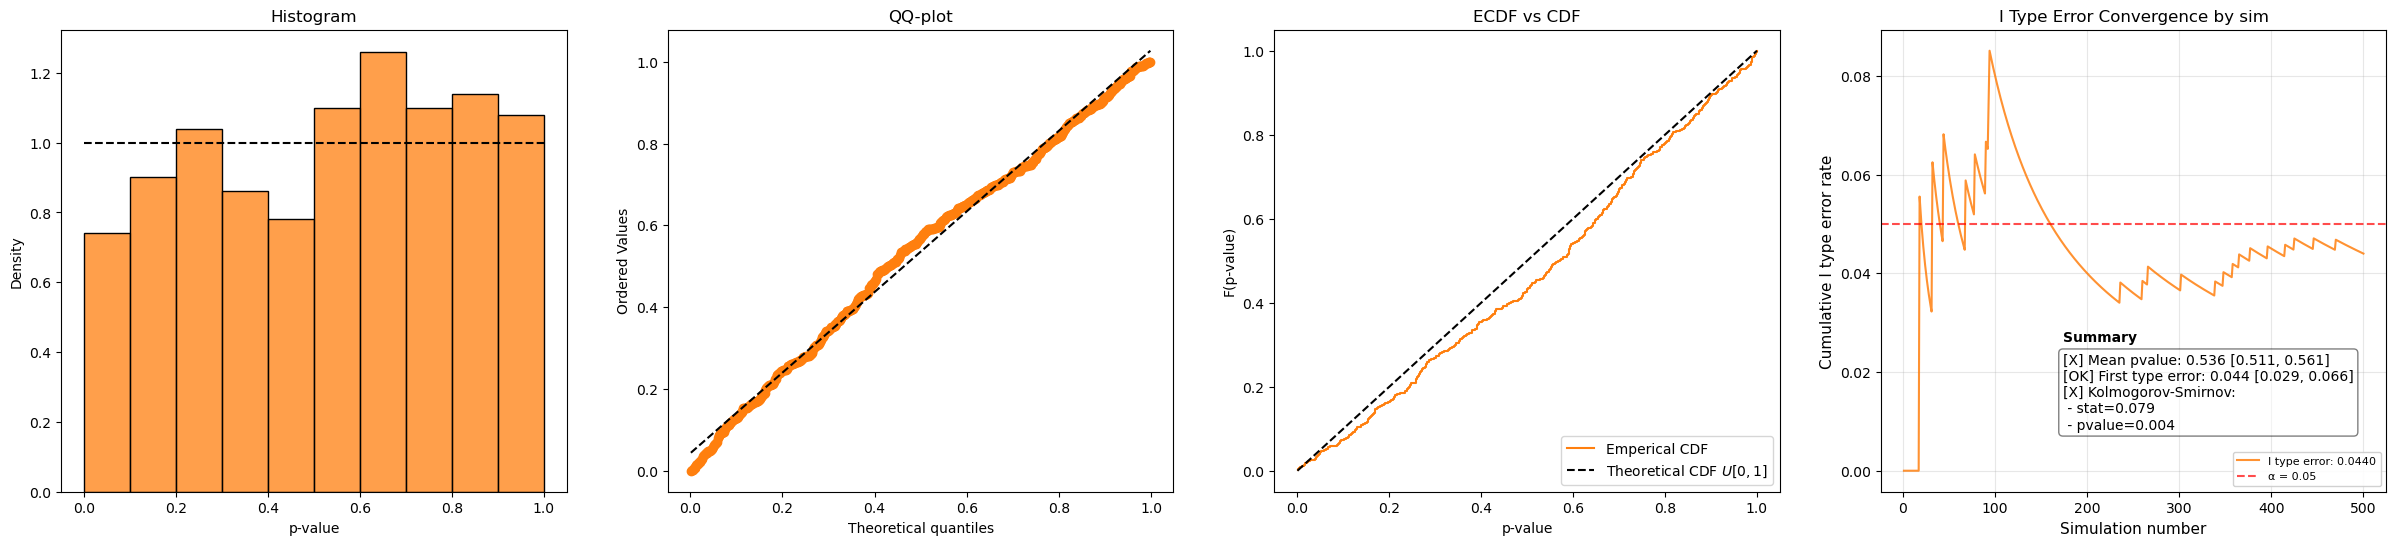

Same seeds → identical p-values: True
Type I error run A: 0.044
Type I error run B: 0.044



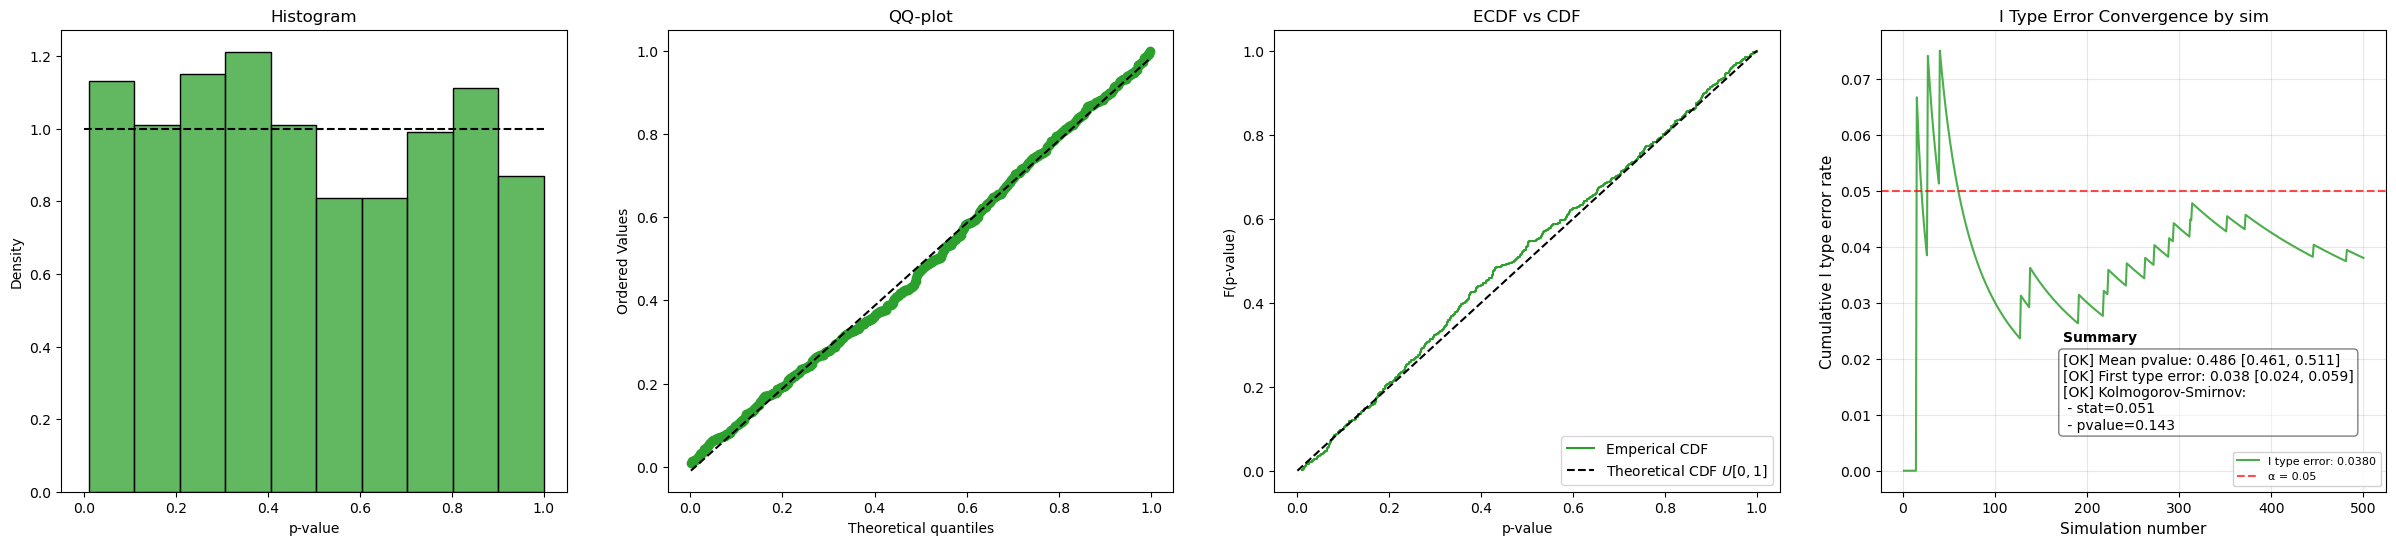

Changed data seed → different p-values: True



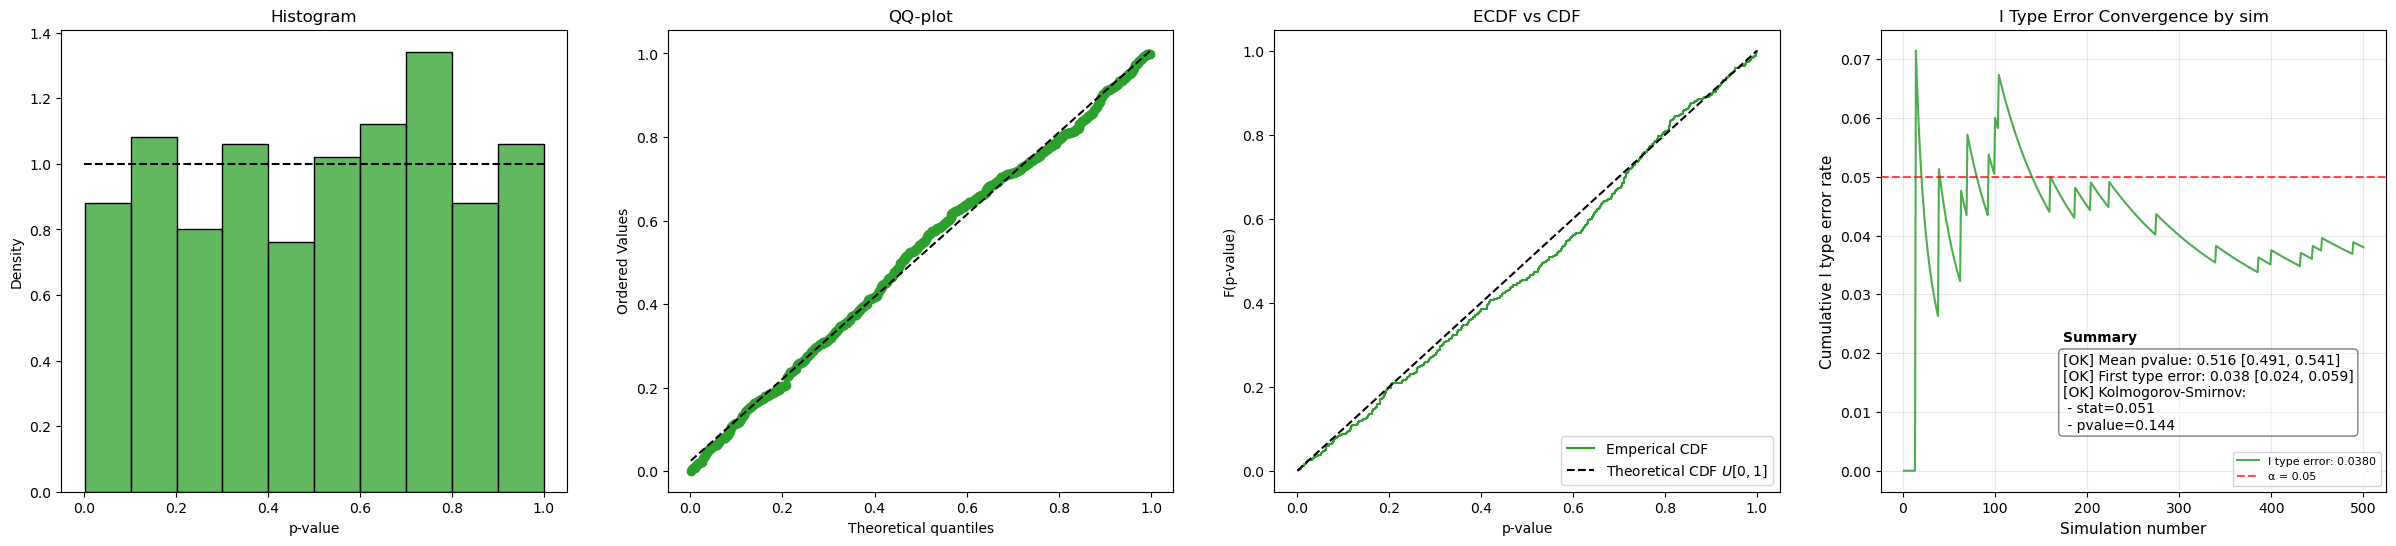

Changed designer seed → different p-values: True


In [1]:
from mcab import RandomData, AaDataIid, DesignerIid
from scipy import stats
import numpy as np

pval_func = lambda t, c: stats.ttest_ind(t, c).pvalue

# ── Full chain, run A ──────────────────────────────────────────────────────────
data_a = RandomData(seed=42).normal_data(size=10_000, mean=100, std=30)
designer_a = DesignerIid(AaDataIid(data_a), seed=42)
pvals_a = designer_a.aa_sims(pval_func=pval_func, n_sims=500, verbose=False)

# ── Full chain, run B — same seeds ────────────────────────────────────────────
data_b = RandomData(seed=42).normal_data(size=10_000, mean=100, std=30)
designer_b = DesignerIid(AaDataIid(data_b), seed=42)
pvals_b = designer_b.aa_sims(pval_func=pval_func, n_sims=500, verbose=False)

print("Same seeds → identical p-values:", np.array_equal(pvals_a, pvals_b))
print("Type I error run A:", (pvals_a < 0.05).mean().round(3))
print("Type I error run B:", (pvals_b < 0.05).mean().round(3))
print()

# ── Change RandomData seed only ───────────────────────────────────────────────
data_c = RandomData(seed=99).normal_data(size=10_000, mean=100, std=30)
designer_c = DesignerIid(AaDataIid(data_c), seed=42)
pvals_c = designer_c.aa_sims(pval_func=pval_func, n_sims=500, verbose=False)

print("Changed data seed → different p-values:", not np.array_equal(pvals_a, pvals_c))
print()

# ── Change Designer seed only ─────────────────────────────────────────────────
data_d = RandomData(seed=42).normal_data(size=10_000, mean=100, std=30)
designer_d = DesignerIid(AaDataIid(data_d), seed=7)
pvals_d = designer_d.aa_sims(pval_func=pval_func, n_sims=500, verbose=False)

print("Changed designer seed → different p-values:", not np.array_equal(pvals_c, pvals_d))


## `DesignerIid`: controlling the simulation seed

`DesignerIid(target, seed=42)` seeds the designer's internal RNG.  
**Creating a new designer object with the same `seed` always produces the same
p-value distribution.**


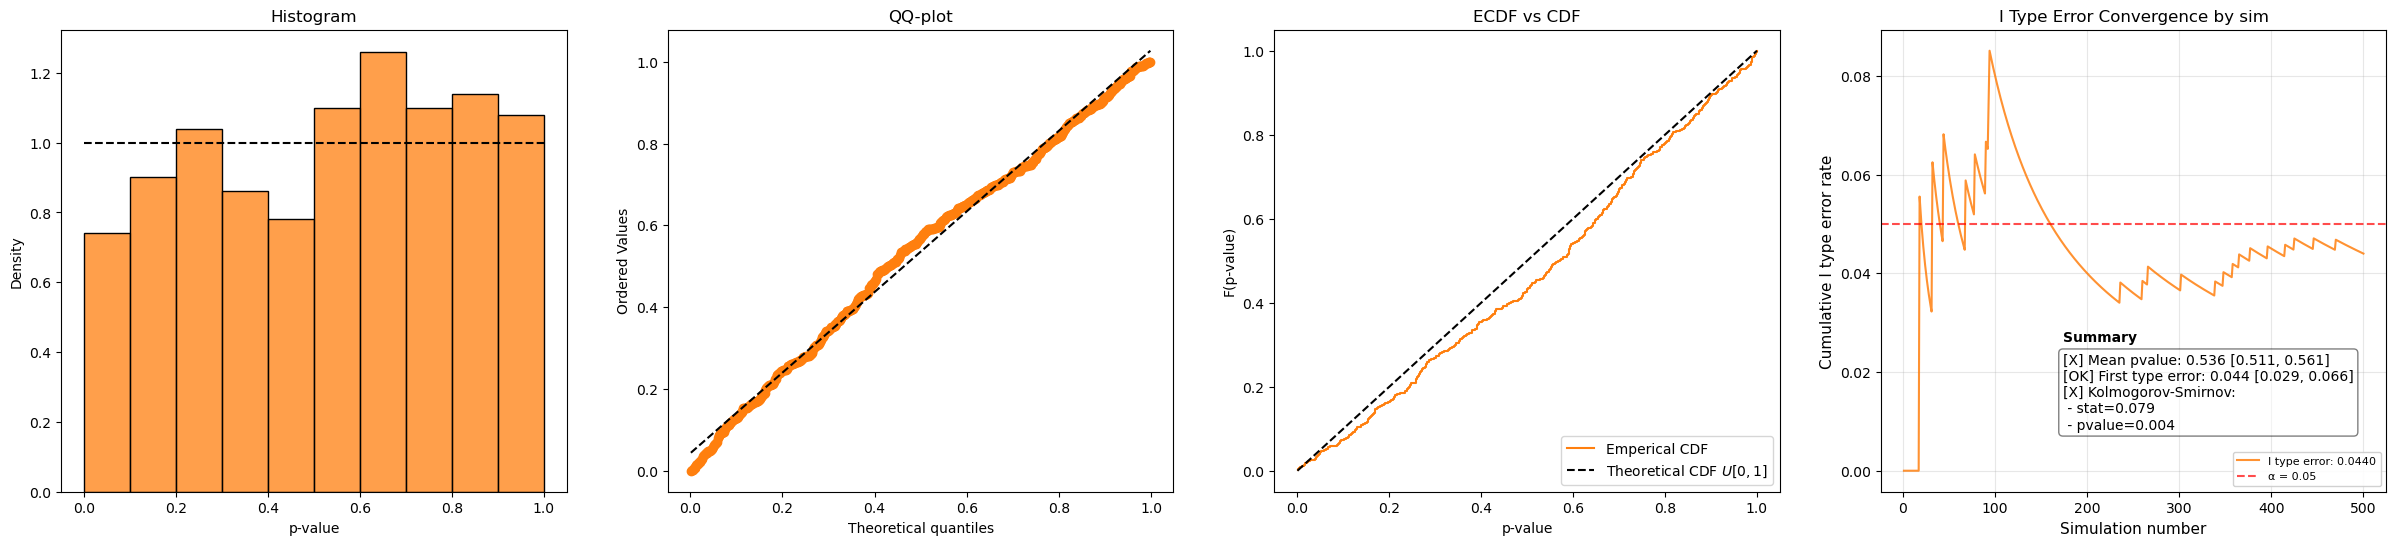

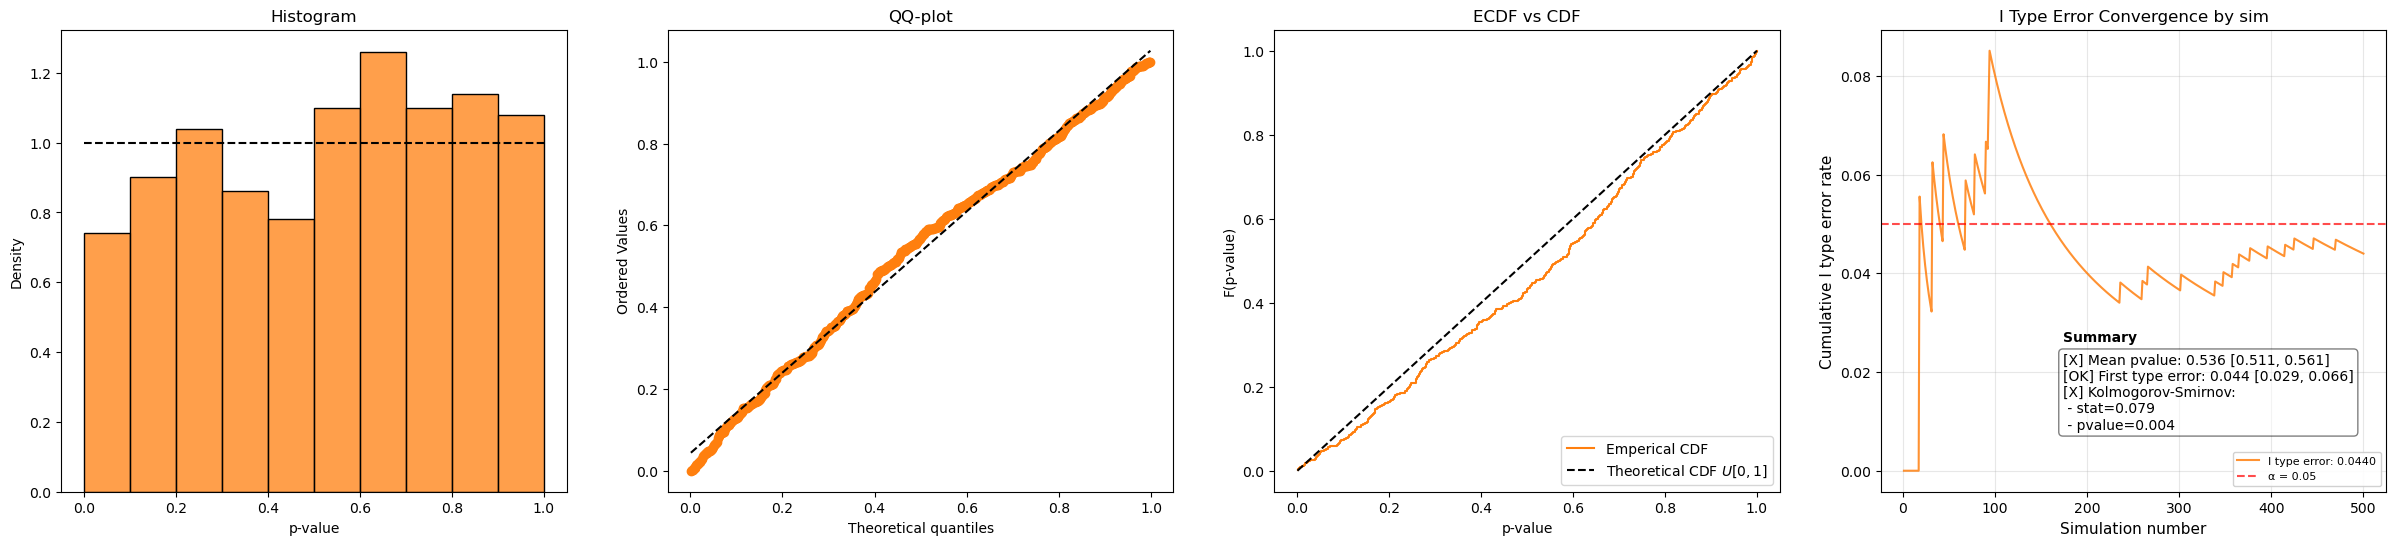

Same seed, new object → identical p-values: True
pvals[:5]: [0.7614 0.3687 0.7475 0.315  0.7862]


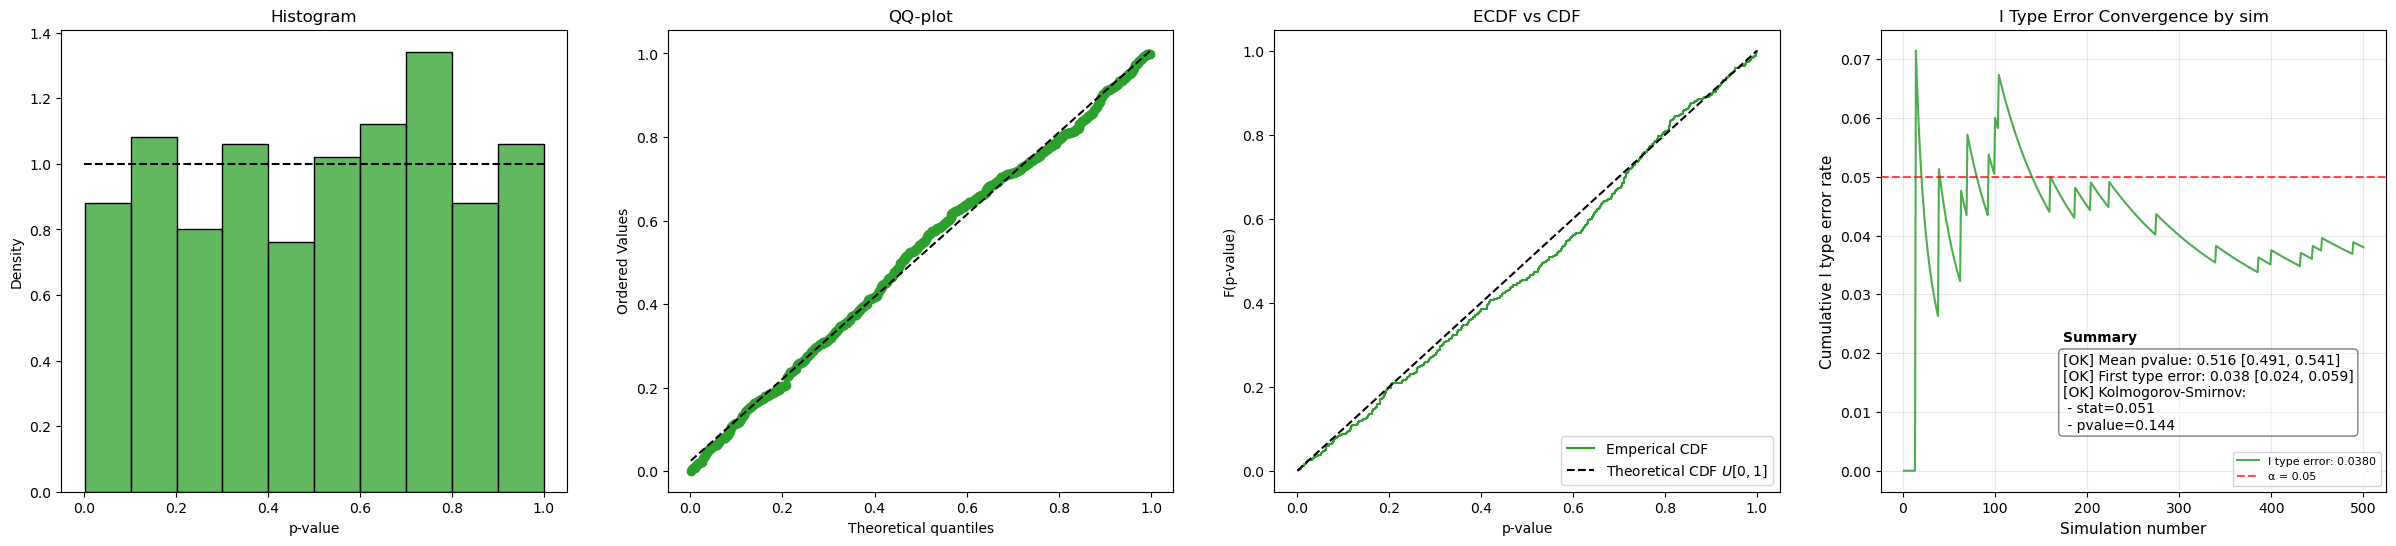


Different seed → different p-values: True


In [2]:
from mcab import AaDataIid, DesignerIid
from scipy import stats

pval_func = lambda t, c: stats.ttest_ind(t, c).pvalue
target = AaDataIid(data_a)

# Run A: new designer with seed=42
designer_a = DesignerIid(target, seed=42)
pvals_a = designer_a.aa_sims(pval_func=pval_func, n_sims=500, verbose=False)

# Run B: new designer with the same seed=42
designer_b = DesignerIid(target, seed=42)
pvals_b = designer_b.aa_sims(pval_func=pval_func, n_sims=500, verbose=False)

print("Same seed, new object → identical p-values:", np.array_equal(pvals_a, pvals_b))
print("pvals[:5]:", pvals_a[:5].round(4))

# Different seed → different (but equally valid) p-values
designer_c = DesignerIid(target, seed=7)
pvals_c = designer_c.aa_sims(pval_func=pval_func, n_sims=500, verbose=False)

print("\nDifferent seed → different p-values:", not np.array_equal(pvals_a, pvals_c))


## ⚠️ Jupyter trap: calling `aa_sims()` twice on the same object

`DesignerIid` stores a **stateful** RNG (`self.rng`). Every call to `aa_sims()`
advances that internal state. If you re-run only the cell with `.aa_sims()` —
without re-running the cell that creates the designer — you get a **different
result each time**.

```
# cell A  ← not re-run
designer = DesignerIid(target, seed=42)

# cell B  ← re-run twice → two different outcomes
pvals = designer.aa_sims(...)
```

**Fix:** keep the designer creation and `aa_sims()` call in the **same cell**,
or always re-run from the top.


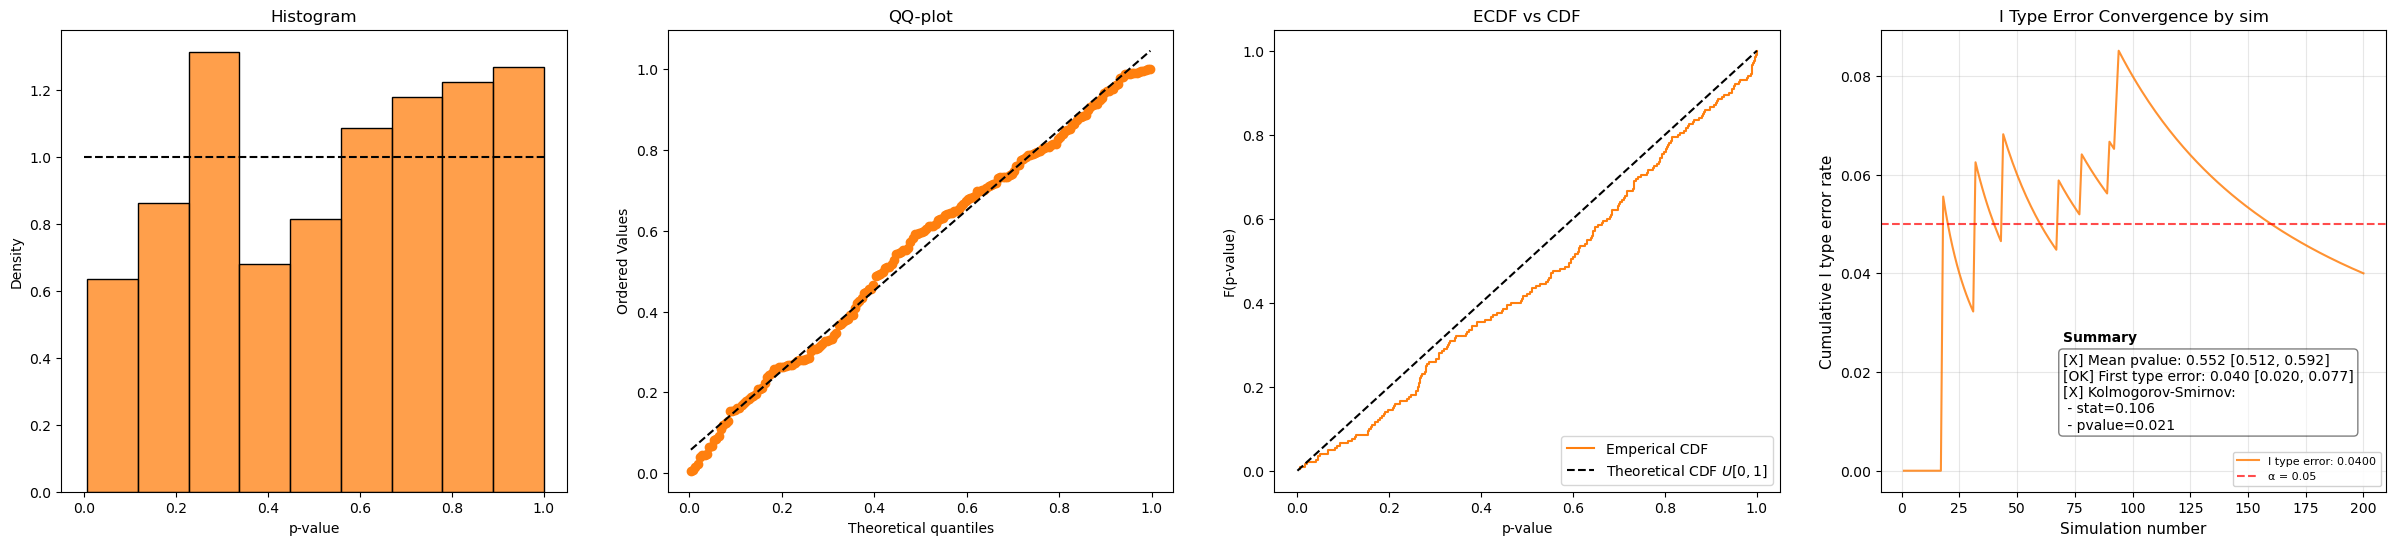

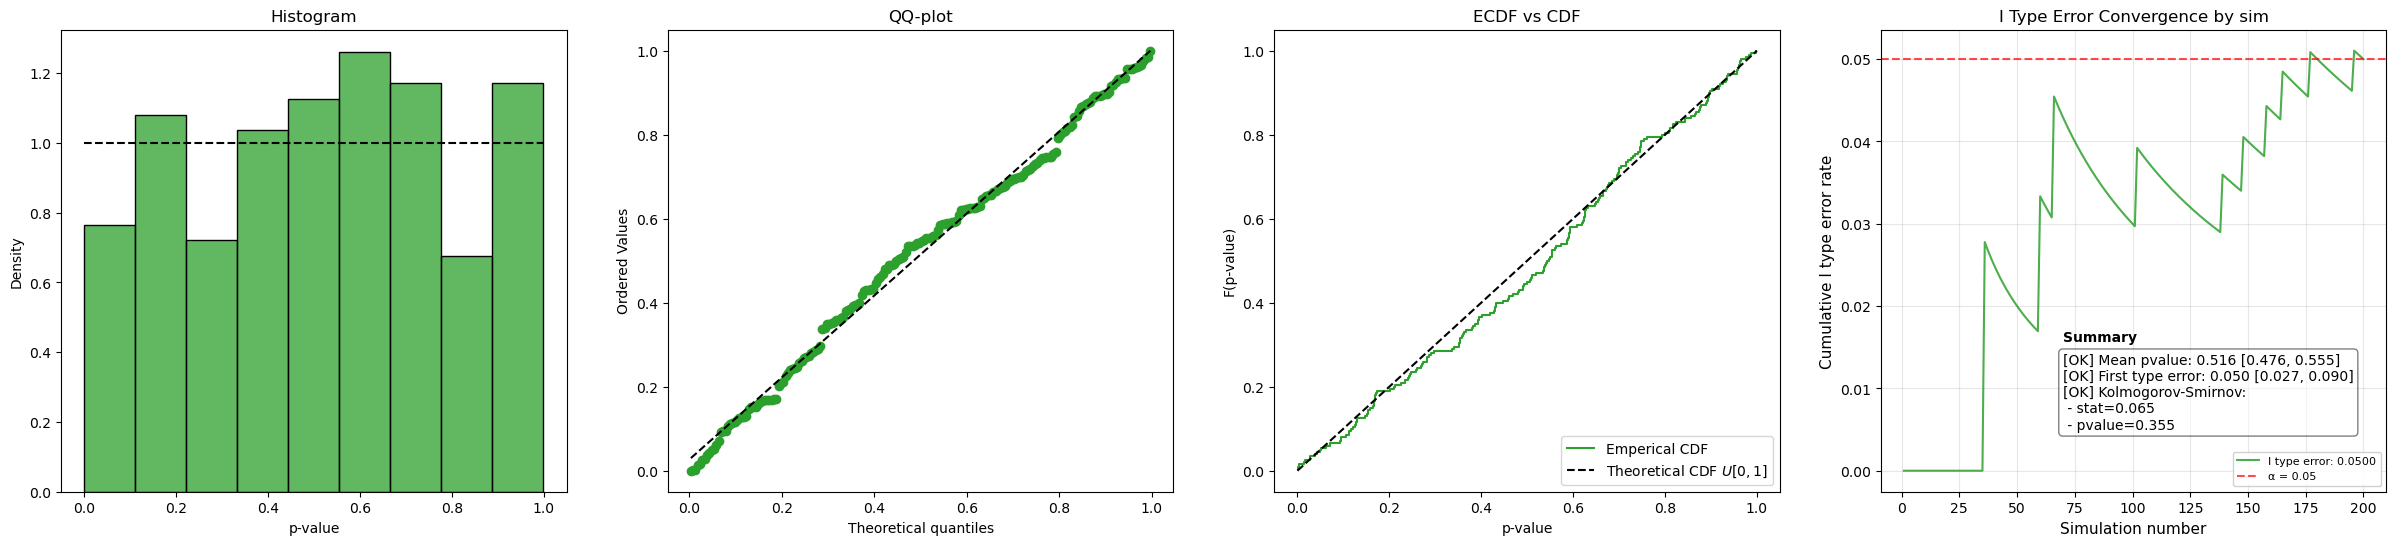

Same object, 2nd call → same result? False
run1[:5]: [0.7614 0.3687 0.7475 0.315  0.7862]
run2[:5]: [0.7336 0.8933 0.5076 0.5743 0.958 ]


In [3]:
# ❌ Anti-pattern: designer created separately, aa_sims re-run in isolation
designer = DesignerIid(target, seed=42)

pvals_run1 = designer.aa_sims(pval_func=pval_func, n_sims=200, verbose=False)
pvals_run2 = designer.aa_sims(pval_func=pval_func, n_sims=200, verbose=False)  # same cell — still different!

print("Same object, 2nd call → same result?", np.array_equal(pvals_run1, pvals_run2))
print("run1[:5]:", pvals_run1[:5].round(4))
print("run2[:5]:", pvals_run2[:5].round(4))


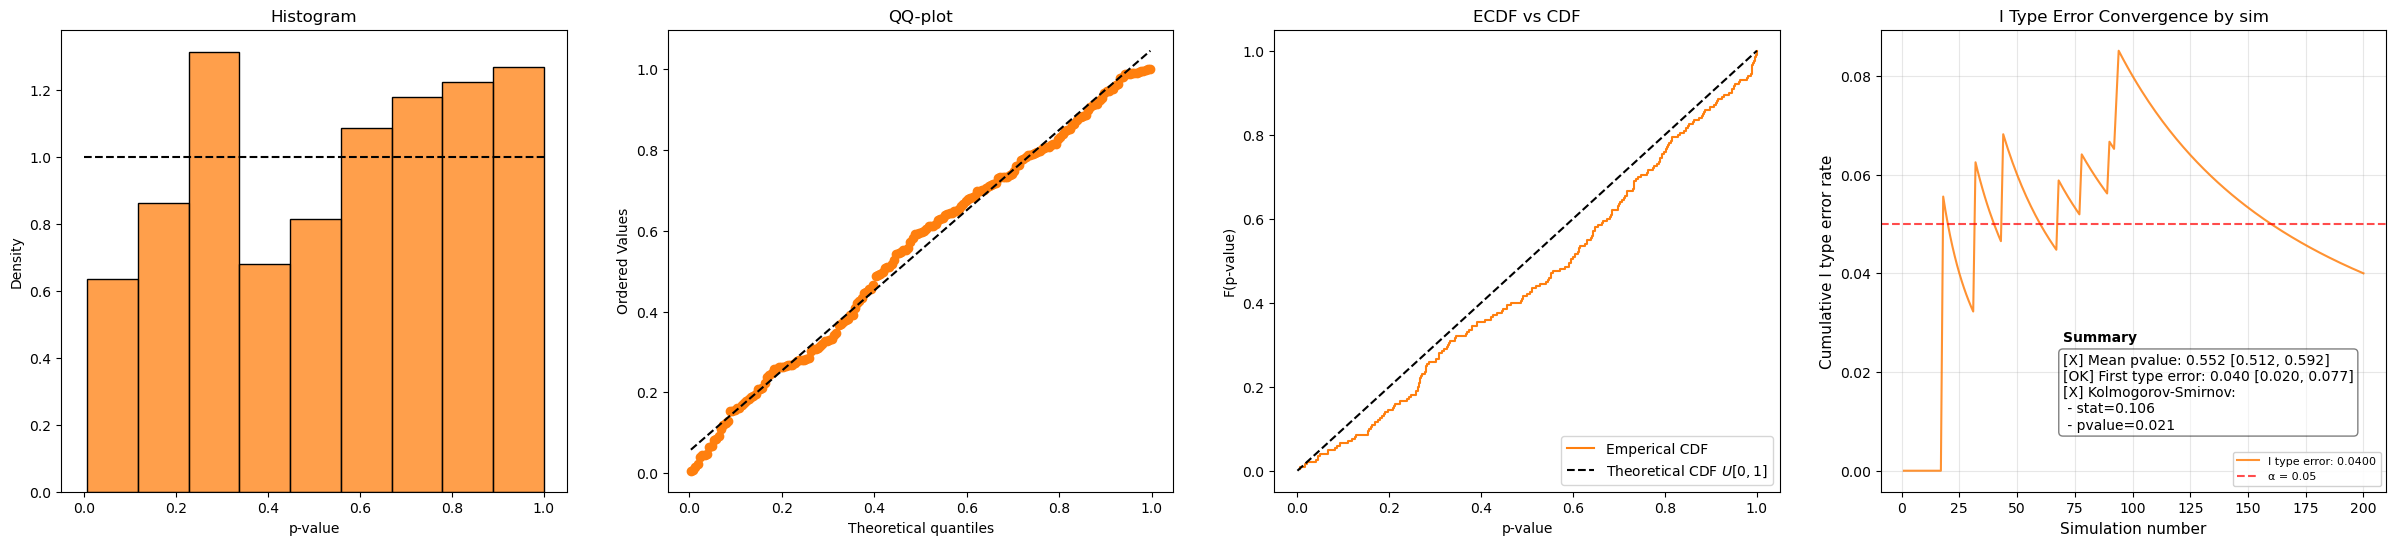

Reproducible every time this cell is re-run
pvals[:5]: [0.7614 0.3687 0.7475 0.315  0.7862]


In [4]:
# ✅ Correct pattern: designer + aa_sims in ONE cell
designer = DesignerIid(target, seed=42)
pvals = designer.aa_sims(pval_func=pval_func, n_sims=200, verbose=False)

print("Reproducible every time this cell is re-run")
print("pvals[:5]:", pvals[:5].round(4))


Result is the same as the first result in previous cell.

## `n_jobs=1` vs `n_jobs=-1`: reproducibility across execution modes

`mcab` uses `joblib` for parallelism. Each simulation with index `i` is seeded
by `np.random.default_rng(i)` — independently of `n_jobs`. This means:

- `n_jobs=1` (sequential) is reproducible across repeated runs ✅
- `n_jobs=-1` (parallel, all cores) is reproducible across repeated runs ✅
- But `n_jobs=1` and `n_jobs=-1` produce **different numbers** from each other —
  because parallel execution does not guarantee iteration order

> **Rule:** pick one `n_jobs` value and don't switch between runs you intend to compare.

| `n_jobs` | Use case |
|----------|----------|
| `1` | Debugging, small `n_sims`, guaranteed order |
| `-1` | Production runs, large `n_sims`, speed matters |


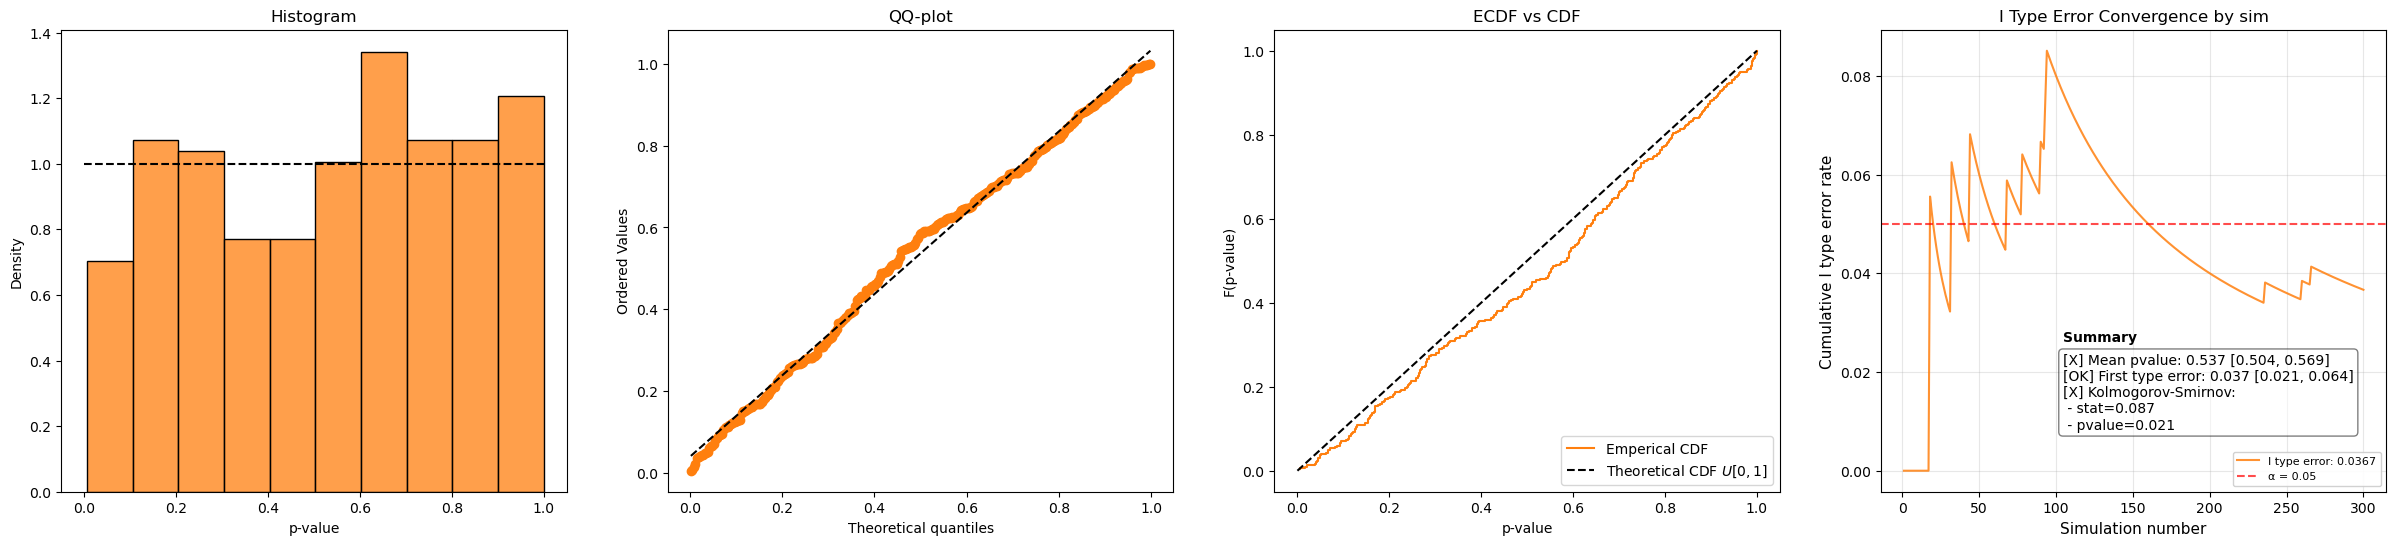

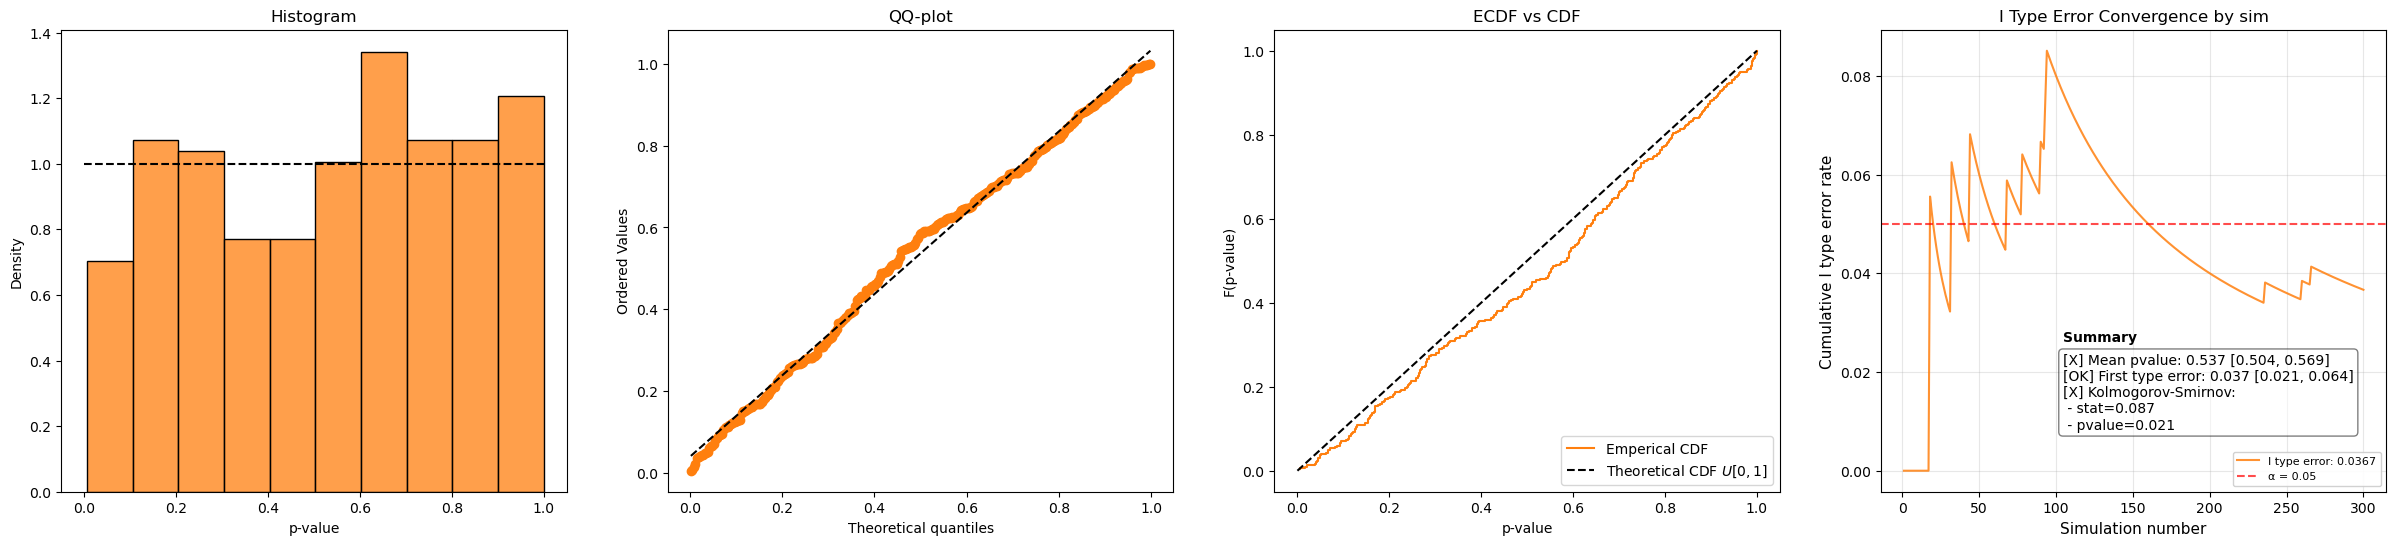

n_jobs=1 run1 == run2: True


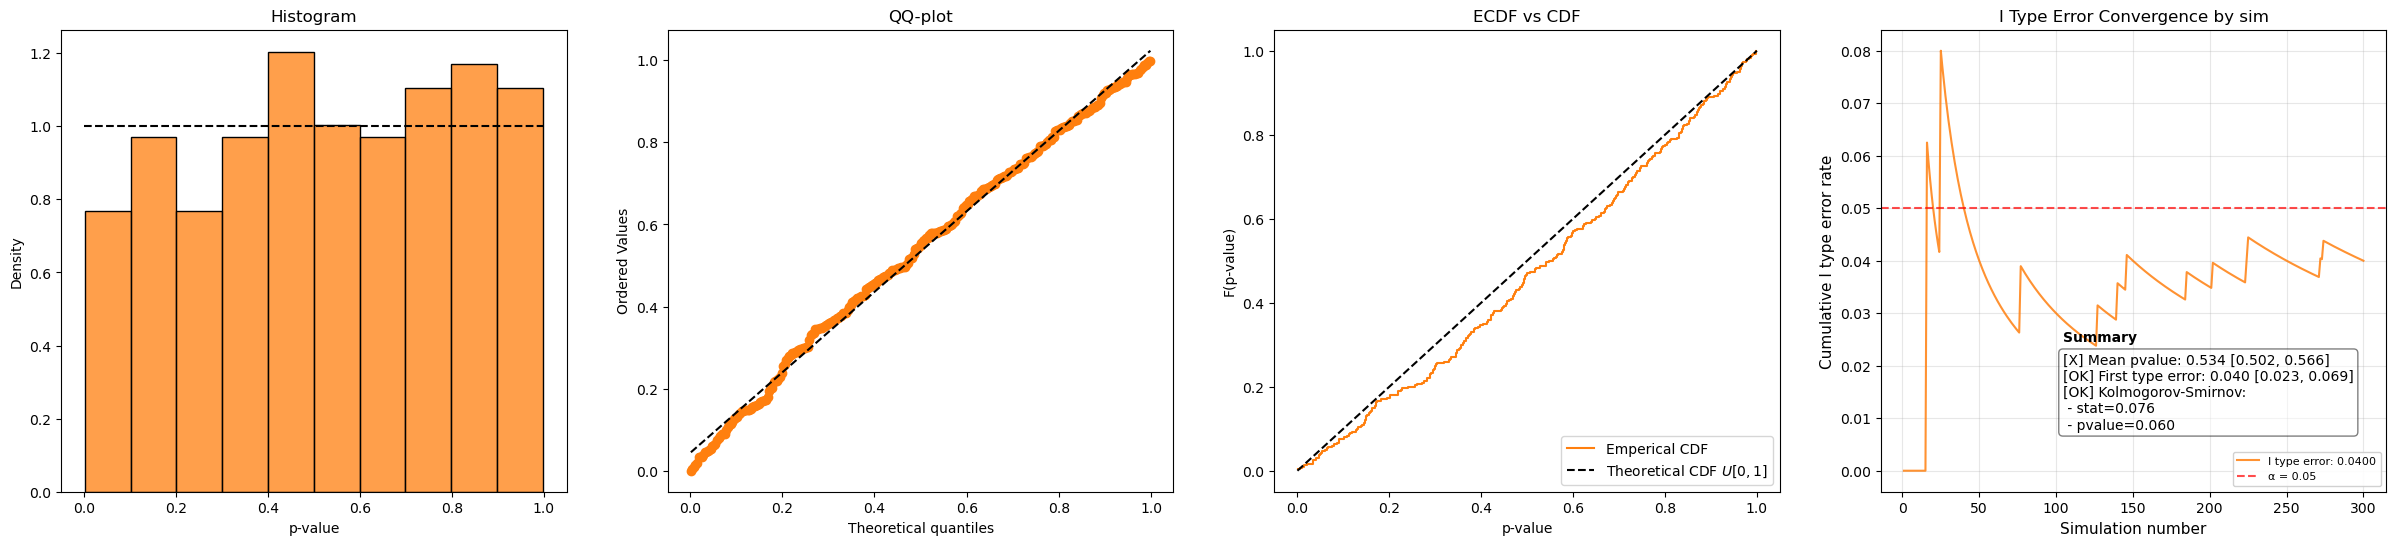

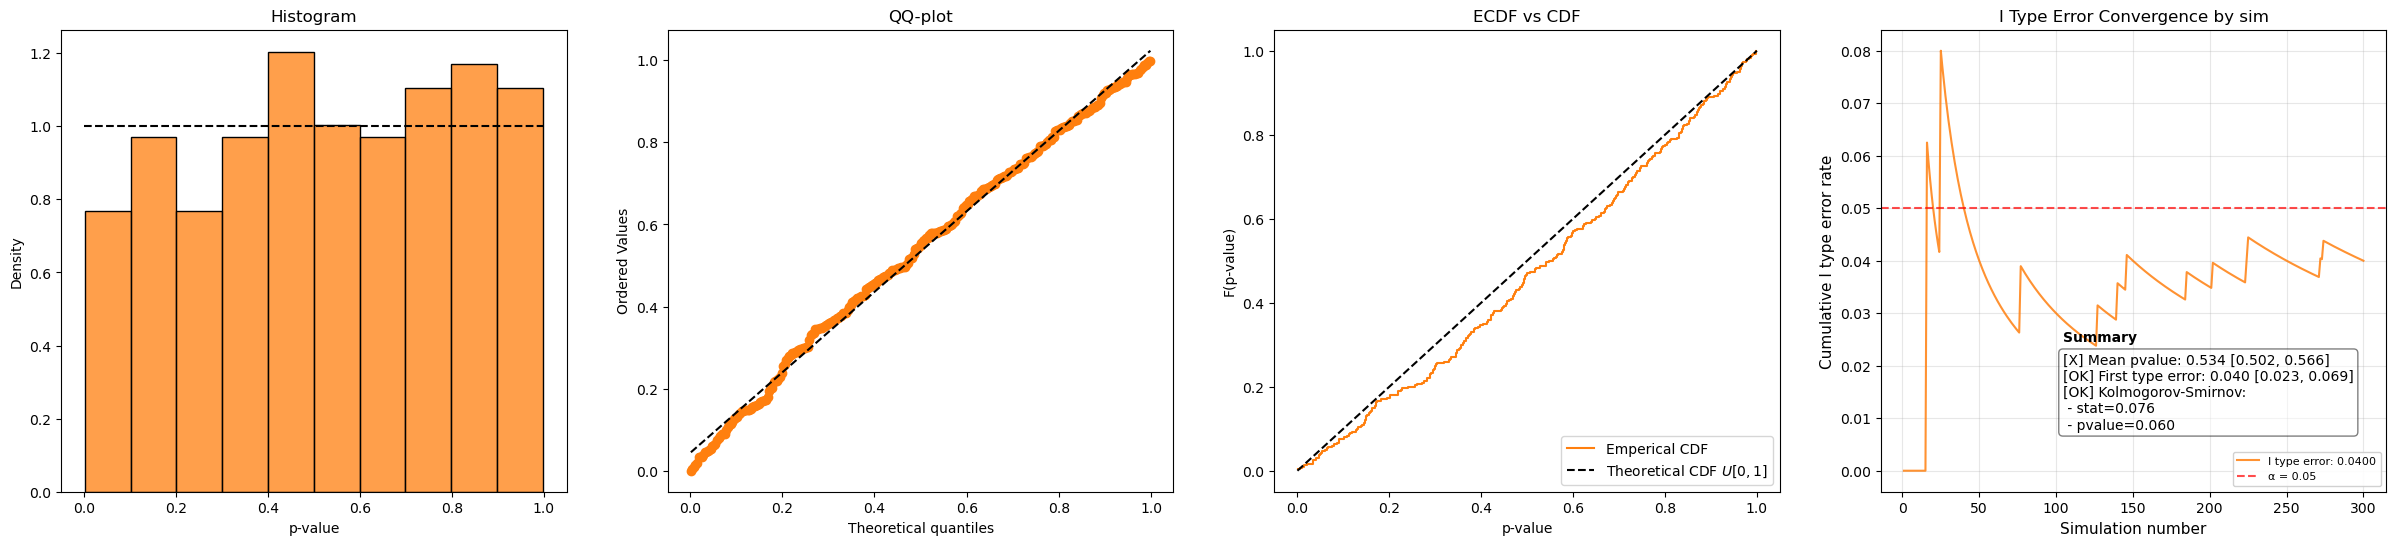

n_jobs=-1 run1 == run2: True

n_jobs=1 == n_jobs=-1: False
→ Different numbers, but both are valid and reproducible within their mode


In [5]:
# n_jobs=1: reproducible
d1 = DesignerIid(target, seed=42)
pvals_seq_1 = d1.aa_sims(pval_func=pval_func, n_sims=300, n_jobs=1, verbose=False)

d2 = DesignerIid(target, seed=42)
pvals_seq_2 = d2.aa_sims(pval_func=pval_func, n_sims=300, n_jobs=1, verbose=False)

print("n_jobs=1 run1 == run2:", np.array_equal(pvals_seq_1, pvals_seq_2))

# n_jobs=-1: reproducible within itself
d3 = DesignerIid(target, seed=42)
pvals_par_1 = d3.aa_sims(pval_func=pval_func, n_sims=300, n_jobs=-1, verbose=False)

d4 = DesignerIid(target, seed=42)
pvals_par_2 = d4.aa_sims(pval_func=pval_func, n_sims=300, n_jobs=-1, verbose=False)

print("n_jobs=-1 run1 == run2:", np.array_equal(pvals_par_1, pvals_par_2))

# But sequential ≠ parallel
print("\nn_jobs=1 == n_jobs=-1:", np.array_equal(pvals_seq_1, pvals_par_1))
print("→ Different numbers, but both are valid and reproducible within their mode")


## Running in a Jupyter Notebook

In Jupyter, `n_jobs=-1` works out of the box — no extra setup needed.
`joblib`'s default `loky` backend handles process spawning safely.

**Recommended notebook pattern:**

```python
# Everything in one cell: designer → sims
from mcab import RandomData, AaDataIid, DesignerIid
from scipy import stats

data = RandomData(seed=42).normal_data(size=10_000, mean=100, std=30)
target = AaDataIid(data)

designer = DesignerIid(target, seed=42)
pvals = designer.aa_sims(
    pval_func=lambda t, c: stats.ttest_ind(t, c).pvalue,
    n_sims=1000,
    n_jobs=-1   # safe in Jupyter
)
```

Re-running this single cell always produces the same result.


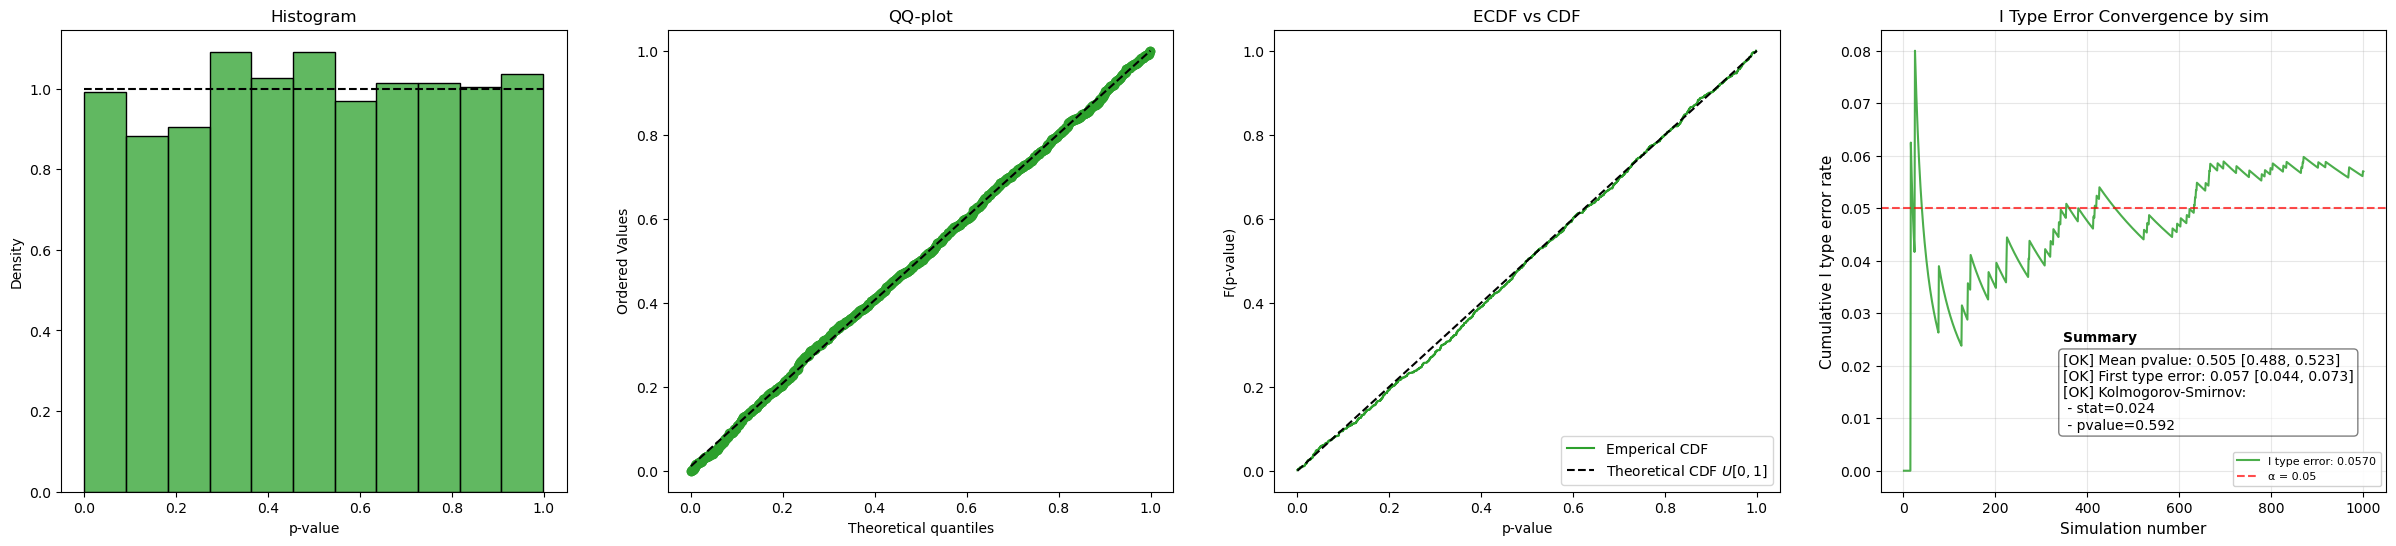

Type I error rate: 0.057


In [6]:
# ✅ Full reproducible Jupyter pattern
from mcab import RandomData, AaDataIid, DesignerIid
from scipy import stats
import numpy as np

# Step 1: data — seed controls what data you get
data = RandomData(seed=42).normal_data(size=10_000, mean=100, std=30)
target = AaDataIid(data)

# Step 2: designer + sims in one shot — seed controls simulation randomness
designer = DesignerIid(target, seed=42)
pvals = designer.aa_sims(
    pval_func=lambda t, c: stats.ttest_ind(t, c).pvalue,
    n_sims=1000,
    n_jobs=-1,  # parallel — safe in Jupyter, fast on large n_sims
    verbose=False
)

print("Type I error rate:", (pvals < 0.05).mean().round(3))


## Running from a Python script

When running `.py` files with `n_jobs > 1`, **you must wrap the entry point** in
`if __name__ == '__main__':`. Without it, each spawned worker process re-imports
the module and tries to launch more workers — causing an infinite fork loop or a
`RuntimeError` on Windows/macOS.

```python
# my_simulation.py
from mcab import RandomData, AaDataIid, DesignerIid
from scipy import stats

def run():
    data = RandomData(seed=42).normal_data(size=10_000, mean=100, std=30)
    target = AaDataIid(data)

    designer = DesignerIid(target, seed=42)
    pvals = designer.aa_sims(
        pval_func=lambda t, c: stats.ttest_ind(t, c).pvalue,
        n_sims=1000,
        n_jobs=-1,
    )
    print("Type I error rate:", (pvals < 0.05).mean().round(3))

if __name__ == '__main__':   # ← required for n_jobs > 1
    run()
```

With `n_jobs=1` the guard is not strictly required, but it's a good habit.


## Summary: reproducibility checklist

| Rule | Why |
|------|-----|
| Always pass explicit `seed=` to `RandomData` | Without it, each run produces different data |
| Always pass explicit `seed=` to `Designer*` | Without it, each newly created object shuffles differently |
| Create the designer and call `aa_sims()` in the **same cell** | Avoids stale RNG state across Jupyter re-runs |
| Pick **one** `n_jobs` value and don't switch | `n_jobs=1` and `n_jobs=-1` produce different (but individually reproducible) results |
| Use `if __name__ == '__main__':` in `.py` scripts with `n_jobs > 1` | Required to avoid recursive worker spawning |
